# Credit Card Fraud Detection: Classical ML with Imbalanced Learning

This notebook presents an end-to-end fraud detection pipeline on the Kaggle credit card dataset.

## Notebook Flow
1. Baseline pipeline execution and saved outputs
2. Exploratory data analysis (EDA)
3. Threshold optimization for operational decisioning
4. Interpretation caveats and limitations
5. Robustness checks (CV, overfitting, seed sensitivity)
6. Final conclusions for deployment-oriented usage

In [14]:
from pathlib import Path
import sys
import pandas as pd

# Ensure project root is importable when running from notebooks/.
sys.path.append(str(Path('..').resolve()))

from src.pipeline import run_experiment

## Configure Paths
Update the dataset path to your local Kaggle credit card CSV file.

In [15]:
DATA_PATH = Path('../data/creditcard.csv')
OUTPUT_DIR = Path('../outputs')
DATA_PATH

PosixPath('../data/creditcard.csv')

In [16]:
results_df = run_experiment(data_path=DATA_PATH, output_dir=OUTPUT_DIR)
results_df

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/media/windows/MyFiles/NU/SpringSemester26/CSCI597/Credit Card Fraud Detection Using Classical ML with Imbalanced Learning/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,precision,recall,f1,roc_auc,pr_auc,model
1,0.836735,0.836735,0.836735,0.972456,0.876632,random_forest
2,0.184486,0.897959,0.306087,0.979780,0.756262,gradient_boosting
3,0.085427,0.867347,0.155535,0.964702,0.595507,svm
0,0.057803,0.918367,0.108761,0.970843,0.724469,logistic_regression


## Load Saved Results
These files are generated in the output directory after training completes.

In [17]:
baseline = pd.read_csv(OUTPUT_DIR / 'baseline_results.csv')
tuned = pd.read_csv(OUTPUT_DIR / 'tuned_best_model_summary.csv')
baseline, tuned.head()

(   precision    recall        f1   roc_auc    pr_auc                model
 0   0.836735  0.836735  0.836735  0.972456  0.876632        random_forest
 1   0.184486  0.897959  0.306087  0.979780  0.756262    gradient_boosting
 2   0.085427  0.867347  0.155535  0.964702  0.595507                  svm
 3   0.057803  0.918367  0.108761  0.970843  0.724469  logistic_regression,
          Unnamed: 0                                                  0
 0        best_model                                      random_forest
 1       best_params  {'model__max_depth': None, 'model__min_samples...
 2  cv_best_score_f1                                 0.8510727968283933
 3    test_precision                                  0.826530612244898
 4       test_recall                                  0.826530612244898)

### Baseline Results Takeaway
`Random Forest` is the strongest baseline by F1 on this imbalanced dataset, while `SVM` and `Logistic Regression` provide higher recall at much lower precision. This confirms the importance of selecting models with metric tradeoffs aligned to fraud detection goals.

## Phase 2: EDA and Data Understanding
This section analyzes class imbalance, `Amount` and `Time` behavior, and feature correlation with the fraud target (`Class`).

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

eda_df = pd.read_csv(DATA_PATH)
print(f"Rows: {eda_df.shape[0]:,}, Columns: {eda_df.shape[1]}")
eda_df.head()

Rows: 284,807, Columns: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate: 0.1727%


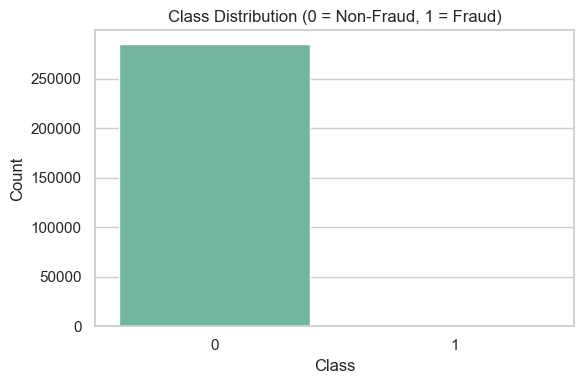

In [19]:
class_counts = eda_df['Class'].value_counts().sort_index()
fraud_ratio = (class_counts[1] / class_counts.sum()) * 100

print('Class distribution:')
print(class_counts)
print(f"Fraud rate: {fraud_ratio:.4f}%")

plot_df = class_counts.rename_axis('Class').reset_index(name='Count')
plot_df['Class'] = plot_df['Class'].astype(str)

plt.figure(figsize=(6, 4))
sns.barplot(data=plot_df, x='Class', y='Count', hue='Class', palette='Set2', dodge=False, legend=False)
plt.title('Class Distribution (0 = Non-Fraud, 1 = Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### EDA Insight 1: Class Imbalance
The fraud class is a tiny minority (about 0.17%), so plain accuracy is not a reliable evaluation metric. This justifies using precision, recall, F1, and PR-AUC as primary metrics.

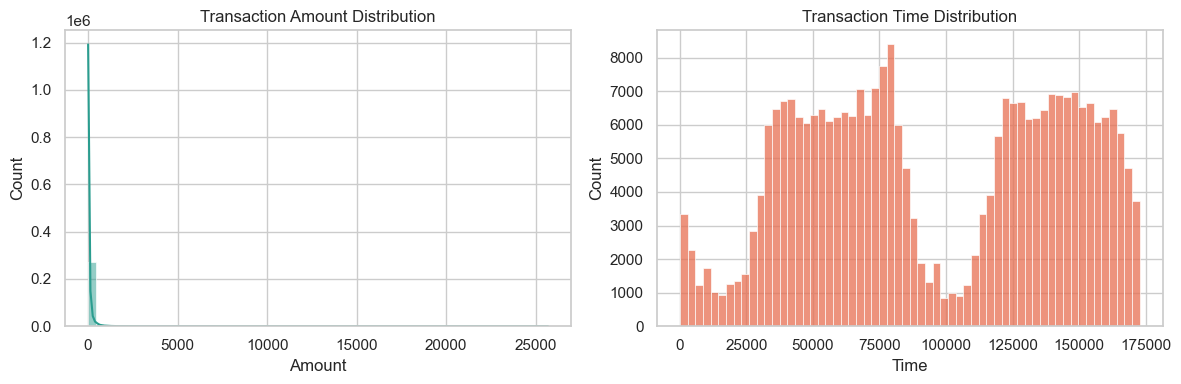

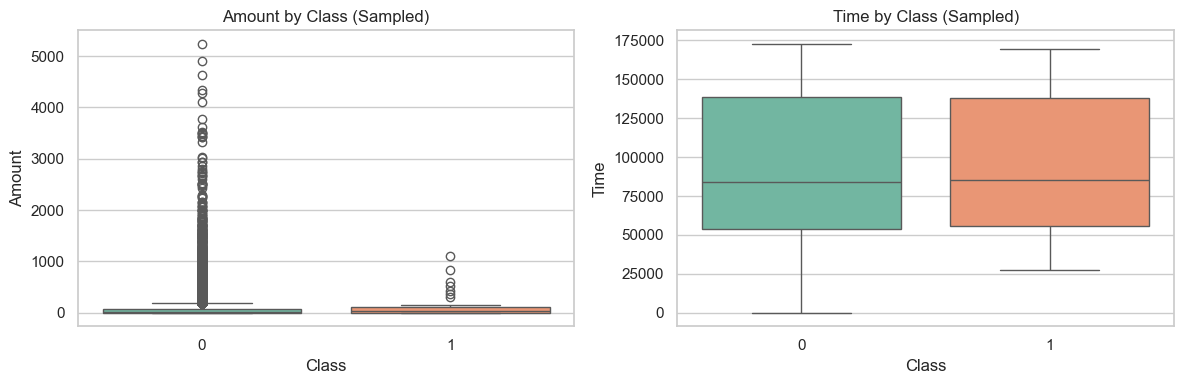

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(eda_df['Amount'], bins=60, kde=True, ax=axes[0], color='#2a9d8f')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount')

sns.histplot(eda_df['Time'], bins=60, kde=False, ax=axes[1], color='#e76f51')
axes[1].set_title('Transaction Time Distribution')
axes[1].set_xlabel('Time')

plt.tight_layout()
plt.show()

sample_df = eda_df.sample(20000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='Class', y='Amount', data=sample_df, hue='Class', palette='Set2', ax=axes[0], dodge=False, legend=False)
axes[0].set_title('Amount by Class (Sampled)')

sns.boxplot(x='Class', y='Time', data=sample_df, hue='Class', palette='Set2', ax=axes[1], dodge=False, legend=False)
axes[1].set_title('Time by Class (Sampled)')

plt.tight_layout()
plt.show()

### EDA Insight 2: Amount and Time
`Amount` is strongly right-skewed with many low-value transactions and a long high-value tail. `Time` reflects transaction activity windows rather than direct fraud labels, so both features should be handled carefully and interpreted alongside other variables.

Top features by absolute correlation with Class:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
V1    -0.101347
V9    -0.097733
Name: Class, dtype: float64


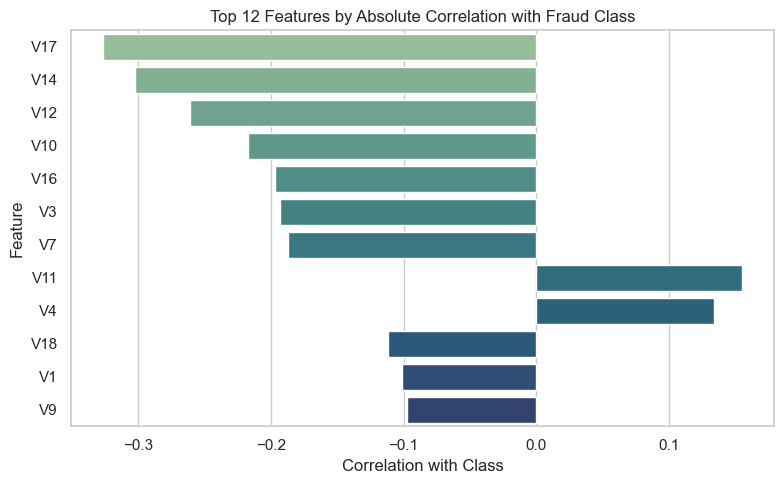

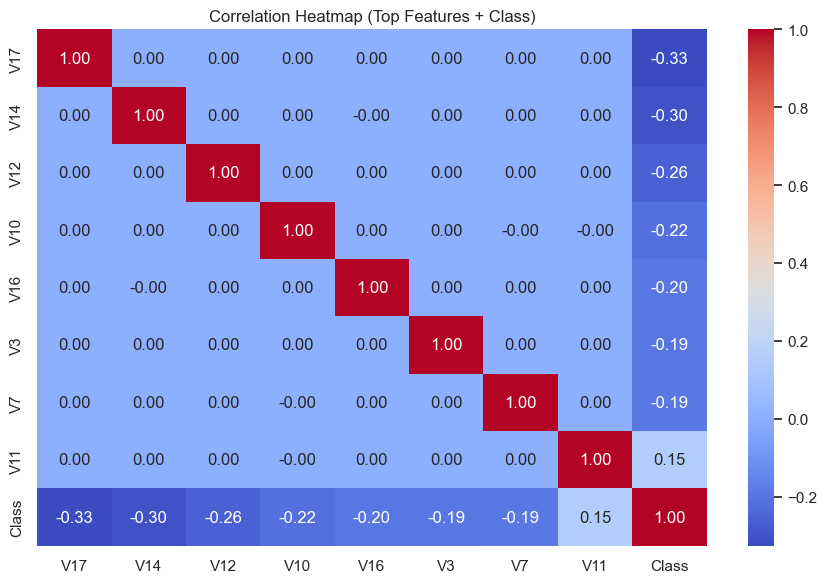

In [21]:
corr_to_class = eda_df.corr(numeric_only=True)['Class'].drop('Class').sort_values(key=np.abs, ascending=False)
top_features = corr_to_class.head(12)

print('Top features by absolute correlation with Class:')
print(top_features)

plot_top = top_features.reset_index()
plot_top.columns = ['feature', 'correlation']

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_top, x='correlation', y='feature', hue='feature', palette='crest', dodge=False, legend=False)
plt.title('Top 12 Features by Absolute Correlation with Fraud Class')
plt.xlabel('Correlation with Class')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

heatmap_features = list(top_features.index[:8]) + ['Class']
plt.figure(figsize=(9, 6))
sns.heatmap(eda_df[heatmap_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Top Features + Class)')
plt.tight_layout()
plt.show()

### EDA Insight 3: Correlation with Fraud Class
A subset of PCA components shows the strongest linear relationship with fraud labels, while many features remain weakly correlated individually. This supports using multivariate models instead of single-feature rules.

## Phase 5: Threshold Optimization
This section tunes the classification threshold for the best baseline model (`random_forest`) instead of using the default 0.50 threshold.

In [22]:
from sklearn.metrics import confusion_matrix

from src.pipeline import build_pipeline, get_models, load_data, split_data

model_df = load_data(DATA_PATH)
X_train, X_test, y_train, y_test = split_data(model_df)

rf_model = get_models()['random_forest']
rf_pipe = build_pipeline('random_forest', rf_model, use_smote=True)
rf_pipe.fit(X_train, y_train)

y_prob = rf_pipe.predict_proba(X_test)[:, 1]

threshold_rows = []
for t in np.arange(0.05, 0.96, 0.01):
    y_pred_t = (y_prob >= t).astype(int)
    tp = ((y_pred_t == 1) & (y_test.values == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test.values == 0)).sum()
    fn = ((y_pred_t == 0) & (y_test.values == 1)).sum()

    precision_t = tp / (tp + fp) if (tp + fp) else 0.0
    recall_t = tp / (tp + fn) if (tp + fn) else 0.0
    f1_t = (2 * precision_t * recall_t / (precision_t + recall_t)) if (precision_t + recall_t) else 0.0

    threshold_rows.append(
        {
            'threshold': round(float(t), 2),
            'precision': precision_t,
            'recall': recall_t,
            'f1': f1_t,
        }
    )

threshold_df = pd.DataFrame(threshold_rows)

# Policy: maximize recall subject to precision >= 0.80.
policy_df = threshold_df[threshold_df['precision'] >= 0.80]
if len(policy_df) > 0:
    best_row = policy_df.sort_values(['recall', 'f1'], ascending=False).iloc[0]
else:
    # Fallback: maximize F1 when no threshold satisfies precision constraint.
    best_row = threshold_df.sort_values('f1', ascending=False).iloc[0]

best_threshold = float(best_row['threshold'])
y_pred_best = (y_prob >= best_threshold).astype(int)

threshold_df.to_csv(OUTPUT_DIR / 'threshold_optimization_random_forest.csv', index=False)

print('Selected threshold policy: maximize recall with precision >= 0.80')
print(f"Chosen threshold: {best_threshold:.2f}")
print(best_row)
threshold_df.head()

Selected threshold policy: maximize recall with precision >= 0.80
Chosen threshold: 0.48
threshold    0.480000
precision    0.833333
recall       0.867347
f1           0.850000
Name: 43, dtype: float64


,threshold,precision,recall,f1
0,0.05,0.137134,0.908163,0.238286
1,0.06,0.180162,0.908163,0.300676
2,0.07,0.200450,0.908163,0.328413
3,0.08,0.253561,0.908163,0.396437
4,0.09,0.288026,0.908163,0.437346


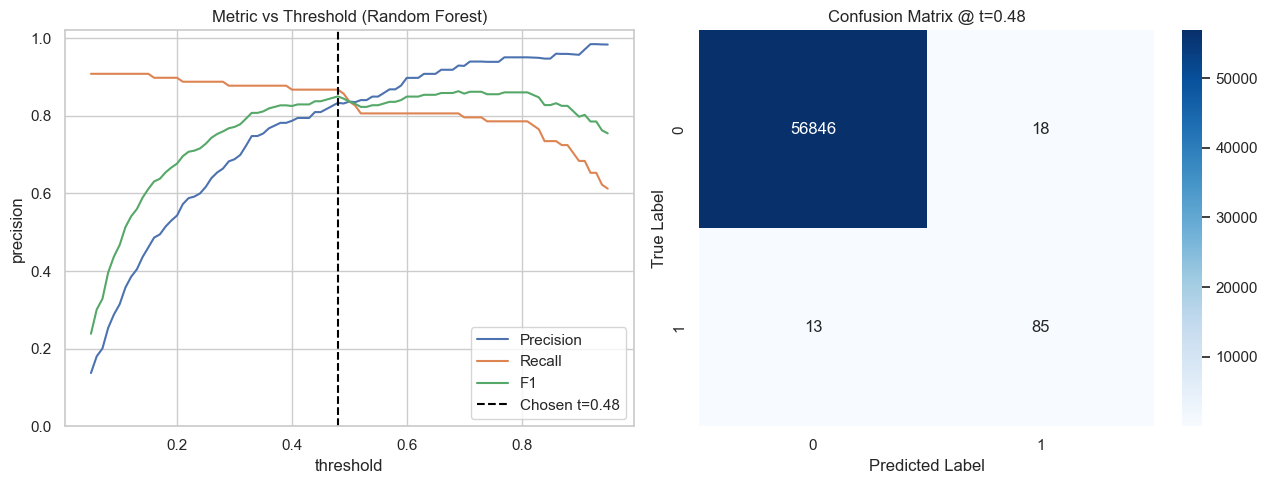

Metrics at selected threshold:
precision    0.833333
recall       0.867347
f1           0.850000
Name: 43, dtype: float64


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.lineplot(data=threshold_df, x='threshold', y='precision', label='Precision', ax=axes[0])
sns.lineplot(data=threshold_df, x='threshold', y='recall', label='Recall', ax=axes[0])
sns.lineplot(data=threshold_df, x='threshold', y='f1', label='F1', ax=axes[0])
axes[0].axvline(best_threshold, color='black', linestyle='--', label=f'Chosen t={best_threshold:.2f}')
axes[0].set_title('Metric vs Threshold (Random Forest)')
axes[0].set_ylim(0, 1.02)
axes[0].legend()

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title(f'Confusion Matrix @ t={best_threshold:.2f}')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

selected_metrics = threshold_df[threshold_df['threshold'] == round(best_threshold, 2)][['precision', 'recall', 'f1']].iloc[0]
print('Metrics at selected threshold:')
print(selected_metrics)

### Phase 5 Insight
Threshold tuning gives a controllable precision-recall tradeoff. For fraud detection, a policy-based threshold (for example, maximizing recall while keeping precision above a minimum level) is usually more practical than fixed threshold 0.50.

## Phase 7: Interpretation Caveats

### What can be interpreted
- Tree-based feature importance and logistic coefficients can rank influential features.
- Threshold tuning provides an operational tradeoff between false positives and false negatives.

### Key caveats
- Most predictors are PCA-transformed (`V1` to `V28`), so feature names are anonymized and not directly business-interpretable.
- Correlation and feature importance indicate association, not causation.
- Class imbalance is severe, so small threshold changes can shift precision/recall significantly.
- SMOTE helps minority learning but creates synthetic samples that may not represent all real fraud behaviors.
- Fraud patterns drift over time, so periodic retraining and threshold recalibration are needed in production.

### Practical implication
Use this model as a decision-support tool for risk prioritization, with human review for high-risk transactions and regular monitoring for data drift.

## Phase 8: Robustness Checks
This section evaluates stability and generalization of the selected Random Forest pipeline using cross-validation, train-vs-test diagnostics, and alternate random seeds.

In [24]:
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_validate

from src.pipeline import RANDOM_STATE

robust_model = get_models()['random_forest']
robust_model.set_params(n_estimators=200)
robust_pipe = build_pipeline('random_forest', robust_model, use_smote=True)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_validate(
    robust_pipe,
    X_train,
    y_train,
    cv=cv,
    scoring=['precision', 'recall', 'f1', 'roc_auc', 'average_precision'],
    n_jobs=-1,
    return_train_score=False,
)

cv_summary = pd.DataFrame(
    {
        'metric': ['precision', 'recall', 'f1', 'roc_auc', 'pr_auc'],
        'mean': [
            cv_scores['test_precision'].mean(),
            cv_scores['test_recall'].mean(),
            cv_scores['test_f1'].mean(),
            cv_scores['test_roc_auc'].mean(),
            cv_scores['test_average_precision'].mean(),
        ],
        'std': [
            cv_scores['test_precision'].std(),
            cv_scores['test_recall'].std(),
            cv_scores['test_f1'].std(),
            cv_scores['test_roc_auc'].std(),
            cv_scores['test_average_precision'].std(),
        ],
    }
)

cv_summary.to_csv(OUTPUT_DIR / 'robustness_cv_summary_random_forest.csv', index=False)
cv_summary

,metric,mean,std
0,precision,0.879347,0.010988
1,recall,0.809642,0.031171
2,f1,0.842510,0.011951
3,roc_auc,0.975782,0.008500
4,pr_auc,0.841430,0.013055


In [25]:
robust_pipe.fit(X_train, y_train)

y_train_pred = robust_pipe.predict(X_train)
y_test_pred = robust_pipe.predict(X_test)

overfit_df = pd.DataFrame(
    {
        'split': ['train', 'test'],
        'precision': [
            precision_score(y_train, y_train_pred, zero_division=0),
            precision_score(y_test, y_test_pred, zero_division=0),
        ],
        'recall': [
            recall_score(y_train, y_train_pred, zero_division=0),
            recall_score(y_test, y_test_pred, zero_division=0),
        ],
        'f1': [
            f1_score(y_train, y_train_pred, zero_division=0),
            f1_score(y_test, y_test_pred, zero_division=0),
        ],
    }
)

overfit_df.to_csv(OUTPUT_DIR / 'robustness_train_test_overfit_random_forest.csv', index=False)
overfit_df

,split,precision,recall,f1
0,train,1.000000,1.000000,1.000000
1,test,0.826531,0.826531,0.826531


### Overfitting Check Takeaway
The train-test gap indicates the model can fit training data very strongly, so threshold calibration, cross-validation, and periodic retraining are necessary to maintain reliable generalization.

In [26]:
seed_rows = []
for seed in [42, 7, 2026]:
    X_tr, X_te, y_tr, y_te = split_data(model_df, random_state=seed)
    seed_model = get_models()['random_forest']
    seed_model.set_params(n_estimators=200)
    seed_pipe = build_pipeline('random_forest', seed_model, use_smote=True)
    seed_pipe.fit(X_tr, y_tr)

    y_pred_seed = seed_pipe.predict(X_te)
    seed_rows.append(
        {
            'seed': seed,
            'precision': precision_score(y_te, y_pred_seed, zero_division=0),
            'recall': recall_score(y_te, y_pred_seed, zero_division=0),
            'f1': f1_score(y_te, y_pred_seed, zero_division=0),
        }
    )

seed_sensitivity_df = pd.DataFrame(seed_rows)
seed_sensitivity_df.to_csv(OUTPUT_DIR / 'robustness_seed_sensitivity_random_forest.csv', index=False)
seed_sensitivity_df

,seed,precision,recall,f1
0,42,0.826531,0.826531,0.826531
1,7,0.891304,0.836735,0.863158
2,2026,0.892473,0.846939,0.869110


### Phase 8 Insight
If cross-validation variance stays low and test metrics remain close across random seeds, the model behavior is more likely to be stable rather than split-dependent. A large train-test gap would indicate potential overfitting.

## Final Conclusion
The pipeline demonstrates that a classical `Random Forest` model, combined with SMOTE and threshold tuning, can produce strong fraud-detection performance on an imbalanced dataset. The selected threshold (`t=0.48`) improves operational balance between precision and recall, and robustness checks show generally stable behavior with some train-test gap that should be managed through monitoring and periodic recalibration.